# 🔍 Détection de Fraude Bancaire — Analyse Exploratoire

Ce notebook constitue la **première étape** d'un projet de Machine Learning appliqué à la détection de fraude sur des transactions par carte bancaire.

## Objectif
Comprendre la structure des données, identifier les déséquilibres de classes et extraire des insights visuels avant toute modélisation.

## Dataset
Le jeu de données `creditcard.csv` contient des transactions bancaires réelles, anonymisées via une **réduction de dimension PCA** (variables V1 à V28).

| Colonne | Description |
|:--------|:------------|
| `Time` | Secondes écoulées depuis la première transaction |
| `V1–V28` | Composantes PCA (anonymisées) |
| `Amount` | Montant de la transaction (en €) |
| `Class` | **0** = Normal, **1** = Fraude |

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(r"C:\Users\aaron\OneDrive\Documents\Projet_GitHub\Fraud_Analysis\data\raw\creditcard.csv")

## Chapitre 1 : Exploration Initiale des Données

Avant de plonger dans les analyses, nous allons :
1. Vérifier les **dimensions** du dataset
2. Afficher un **aperçu** des premières lignes
3. Calculer les **statistiques descriptives** de chaque variable

In [4]:
lignes, colonnes = df.shape
print(f"Le dataset contient {lignes:,} transactions et {colonnes} variables.")
print("-" * 30)
print("Aperçu des 10 premières transactions :")
display(df.head(10))

Le dataset contient 284,807 transactions et 31 variables.
------------------------------
Aperçu des 10 premières transactions :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
print("Statistiques descriptives de chaque colonne :")
df.describe()

Statistiques descriptives de chaque colonne :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Chapitre 2 : Analyse du Déséquilibre de Classes

La variable cible `Class` est **fortement déséquilibrée** : les fraudes représentent une infime proportion des transactions. Ce déséquilibre est un défi majeur pour l'entraînement des modèles de Machine Learning.

> ⚠️ Un modèle qui prédit toujours "Normal" aurait une accuracy de ~99.8% sans jamais détecter une seule fraude !

In [6]:
fraude = df[df['Class'] == 1].shape[0]
normale = df[df['Class'] == 0].shape[0]

print("Répartition des classes (0: Normal, 1: Fraude) :")
print(df['Class'].value_counts(normalize=True) * 100)
print("-" * 30)
print(f"Nombre de transactions frauduleuses : {fraude}")
print(f"Nombre de transactions normales     : {normale}")

Répartition des classes (0: Normal, 1: Fraude) :
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
------------------------------
Nombre de transactions frauduleuses : 492
Nombre de transactions normales     : 284315


### Visualisation du déséquilibre

Le graphique suivant illustre visuellement l'écart entre les deux classes. Nous utilisons ensuite une **échelle logarithmique** pour mieux percevoir la différence.

C:\Users\aaron\AppData\Local\Temp\ipykernel_13064\318885981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette=['blue', 'red'], ax=ax1)
C:\Users\aaron\AppData\Local\Temp\ipykernel_13064\318885981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette=['blue', 'red'], ax=ax2)


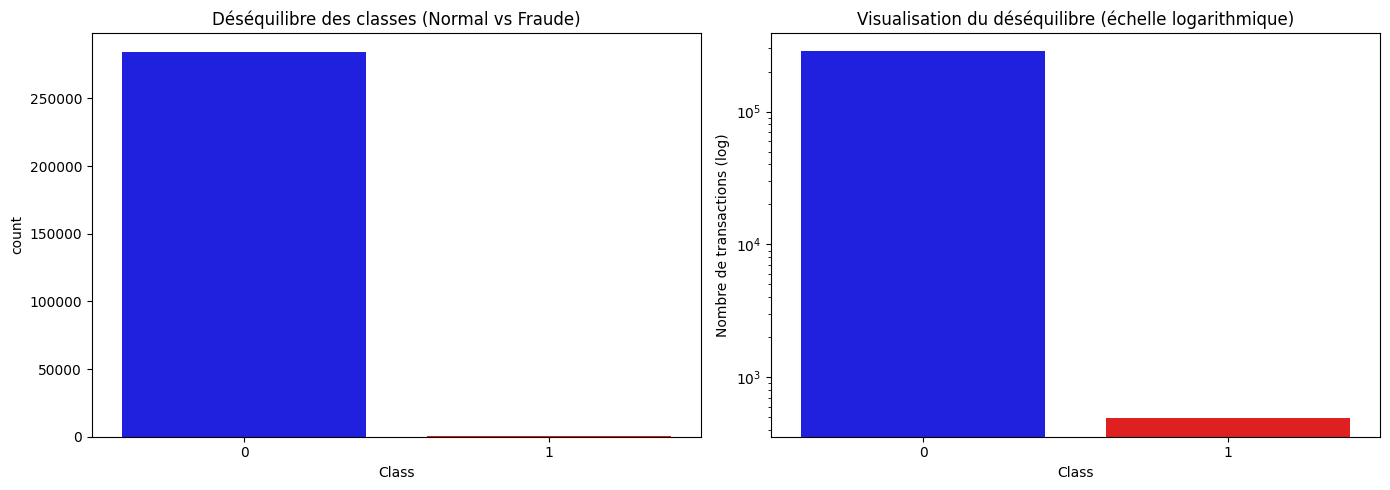

➡ Le déséquilibre est ÉNORME : les fraudes représentent moins de 0.2% des transactions.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Class', palette=['blue', 'red'], ax=ax1)
ax1.set_title("Déséquilibre des classes (Normal vs Fraude)")

sns.countplot(data=df, x='Class', palette=['blue', 'red'], ax=ax2)
ax2.set_yscale('log')
ax2.set_title("Visualisation du déséquilibre (échelle logarithmique)")
ax2.set_ylabel("Nombre de transactions (log)")

plt.tight_layout()
plt.show()
print("➡ Le déséquilibre est ÉNORME : les fraudes représentent moins de 0.2% des transactions.")

## Chapitre 3 : Analyse des Montants des Transactions

Une question naturelle se pose : **les fraudeurs opèrent-ils sur des montants différents des transactions normales ?**

Un boxplot permet de visualiser la distribution des montants pour chaque classe et d'identifier d'éventuels patterns.

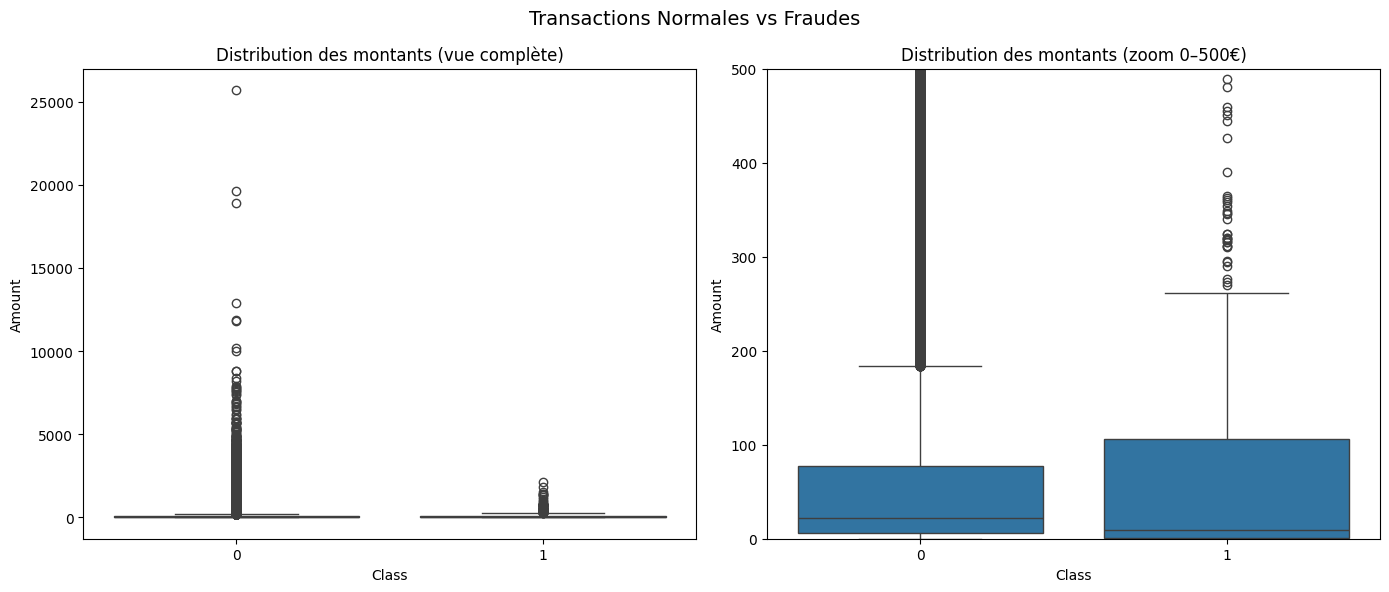

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Class', y='Amount', ax=ax1)
ax1.set_title("Distribution des montants (vue complète)")

sns.boxplot(data=df, x='Class', y='Amount', ax=ax2)
ax2.set_ylim(0, 500)
ax2.set_title("Distribution des montants (zoom 0–500€)")

plt.suptitle("Transactions Normales vs Fraudes", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
stats_amount = df.groupby('Class')['Amount'].describe()
print("Statistiques détaillées des montants par classe :")
display(stats_amount)

medians = df.groupby('Class')['Amount'].median()
print(f"\nMédiane des transactions normales     : {medians[0]:.2f} €")
print(f"Médiane des transactions frauduleuses : {medians[1]:.2f} €")

Statistiques détaillées des montants par classe :


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87



Médiane des transactions normales     : 22.00 €
Médiane des transactions frauduleuses : 9.25 €


## Chapitre 3.2 : Analyse Temporelle des Transactions

La variable `Time` représente les secondes écoulées depuis la première transaction du dataset. Nous allons analyser si les fraudes se concentrent sur des **plages horaires particulières**.

> 🕵️ L'hypothèse intuitive serait que les fraudeurs agissent davantage la nuit, quand la vigilance est réduite.

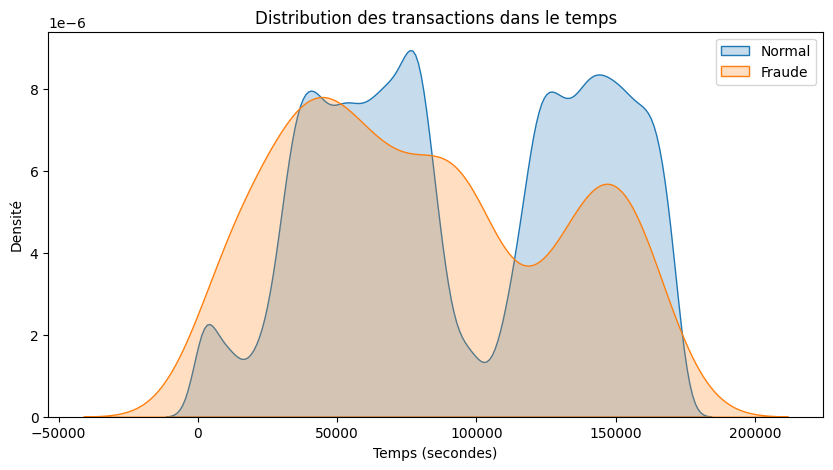

➡ Contrairement aux clients normaux, les fraudeurs n'ont pas de creux nocturne : ils agissent 24h/24.


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df[df['Class'] == 0]['Time'], label='Normal', ax=ax, fill=True)
sns.kdeplot(df[df['Class'] == 1]['Time'], label='Fraude', ax=ax, fill=True)

plt.title("Distribution des transactions dans le temps")
plt.xlabel("Temps (secondes)")
plt.ylabel("Densité")
plt.legend()
plt.show()

print("➡ Contrairement aux clients normaux, les fraudeurs n'ont pas de creux nocturne : ils agissent 24h/24.")

## Chapitre 3.3 : Matrice de Corrélation (Heatmap)

La heatmap des corrélations nous permet d'identifier quelles **composantes PCA (V1–V28)** sont les plus corrélées avec la variable `Class`.

Ces variables seront des candidats prioritaires pour nos modèles de détection.

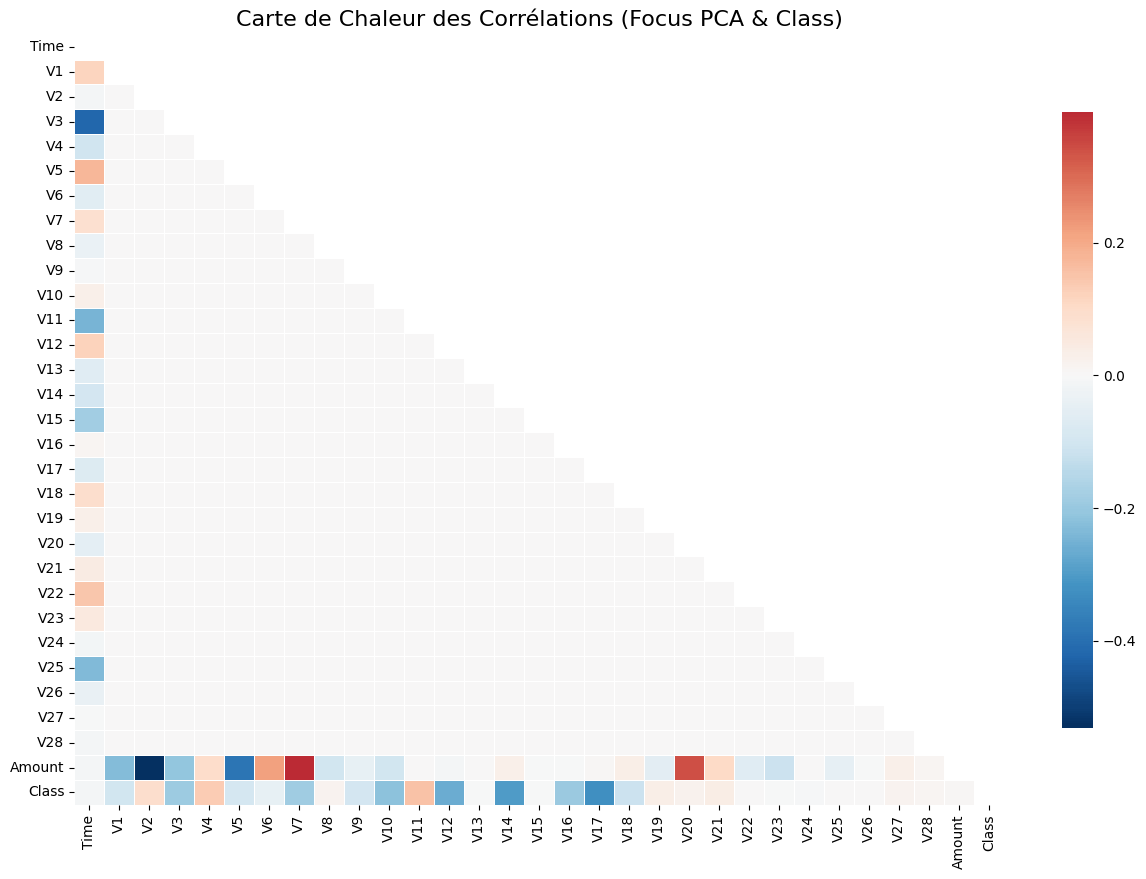

In [11]:
matrice_corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(matrice_corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Carte de Chaleur des Corrélations (Focus PCA & Class)', fontsize=16)
plt.show()

## Chapitre 3.4 : Analyse du Rythme Horaire

Nous allons convertir la variable `Time` (en secondes) en **heures de la journée** (0h–23h) pour analyser les habitudes des fraudeurs vs les clients normaux.

Vérification de la conversion (Time vs Hour) :


,Time,Hour
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,1.0,0.0
4,2.0,0.0



Plage d'heures générée : de 0.0h à 23.0h


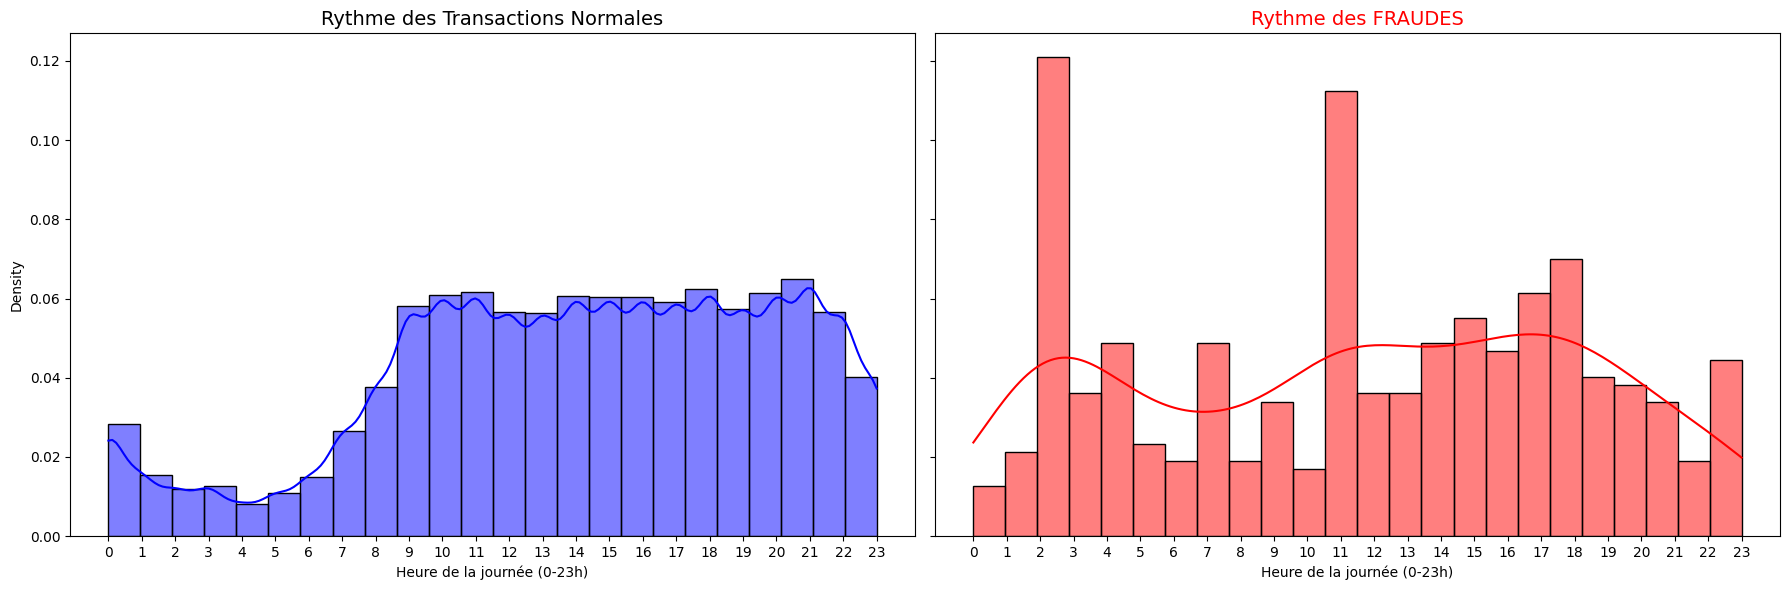

In [12]:
df['Hour'] = (df['Time'] // 3600) % 24

print("Vérification de la conversion (Time vs Hour) :")
display(df[['Time', 'Hour']].head())
print(f"\nPlage d'heures générée : de {df['Hour'].min()}h à {df['Hour'].max()}h")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.histplot(df[df['Class'] == 0]['Hour'], bins=24, kde=True, color='blue', stat="density", ax=ax1)
ax1.set_title("Rythme des Transactions Normales", fontsize=14)
ax1.set_xlabel("Heure de la journée (0-23h)")
ax1.set_xticks(range(0, 24))

sns.histplot(df[df['Class'] == 1]['Hour'], bins=24, kde=True, color='red', stat="density", ax=ax2)
ax2.set_title("Rythme des FRAUDES", fontsize=14, color='red')
ax2.set_xlabel("Heure de la journée (0-23h)")
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

## Chapitre 3.5 : Évolution du Taux de Fraude dans le Temps

Pour détecter d'éventuelles **vagues de fraude**, nous calculons une **moyenne glissante** du taux de fraude sur 500 transactions consécutives.

> ⚠️ **Note** : Le chapitre sur les habitudes d'achat par tranche de montant (`Amount_Group`) a été retiré car la colonne correspondante n'est pas créée dans ce notebook.

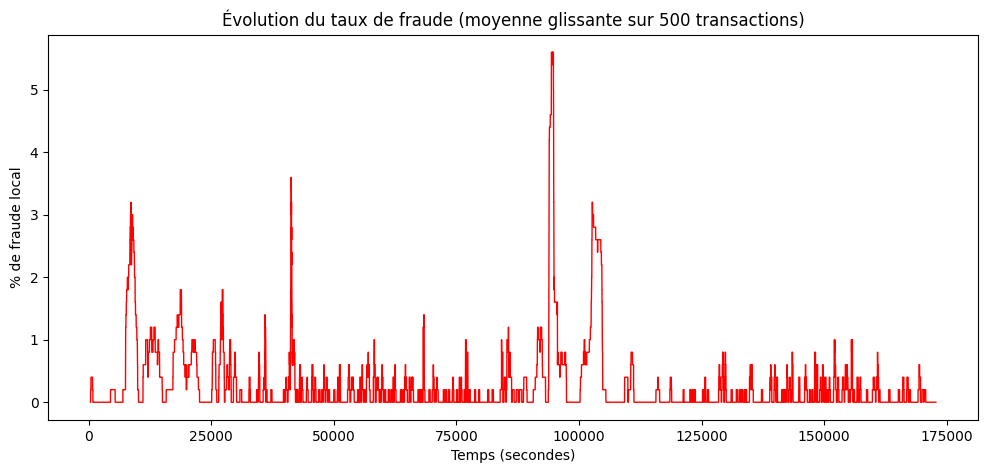

In [13]:
vagues_fraude = df['Class'].rolling(window=500).mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(df['Time'], vagues_fraude, color='red', linewidth=1)
plt.title("Évolution du taux de fraude (moyenne glissante sur 500 transactions)")
plt.xlabel("Temps (secondes)")
plt.ylabel("% de fraude local")
plt.show()

## Chapitre 3.6 : Séparabilité Visuelle — Pairplot des Variables Clés

Sur la base de la heatmap de corrélation, nous avons identifié les variables **V17, V14 et V12** comme les plus discriminantes.

Un **pairplot** permet de visualiser si ces variables permettent de séparer visuellement les fraudes des transactions normales.

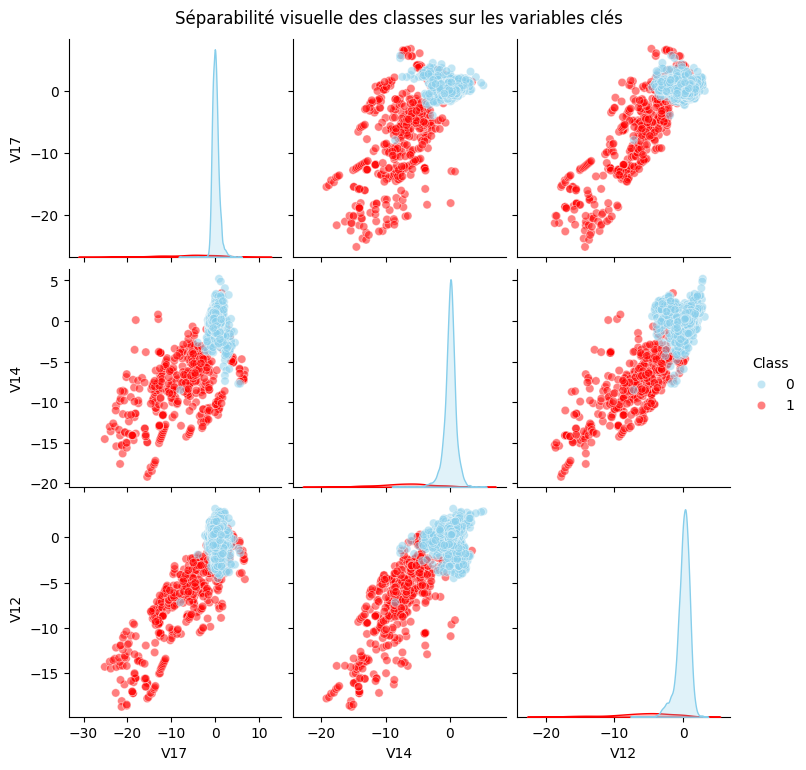

In [14]:
variables_cles = ['V17', 'V14', 'V12', 'Class']

df_fraude = df[df['Class'] == 1]
df_normale_sample = df[df['Class'] == 0].sample(5000, random_state=42)
df_plot = pd.concat([df_fraude, df_normale_sample])

sns.pairplot(df_plot[variables_cles], hue='Class',
             palette={0: 'skyblue', 1: 'red'},
             plot_kws={'alpha': 0.5})

plt.suptitle("Séparabilité visuelle des classes sur les variables clés", y=1.02)
plt.show()

---
# Partie 2 : Preprocessing & Modélisation

L'exploration des données a mis en évidence deux défis principaux :
- Un **déséquilibre de classes** massif (0.17% de fraudes)
- Des **variables non normalisées** (`Amount`, `Hour`) à mettre à l'échelle

Nous allons maintenant préparer les données pour l'entraînement des modèles.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import recall_score, f1_score, precision_score, precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
import joblib

### Scaling & Split Train/Test

Nous appliquons un **RobustScaler** sur les colonnes `Amount` et `Hour` car elles ne sont pas issues de la PCA. Ce scaler est résistant aux valeurs extrêmes (outliers) grâce à l'utilisation de la médiane et de l'IQR.

Le split est **stratifié** pour conserver le même ratio de fraudes dans les deux ensembles.

In [16]:
X = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

scaler = RobustScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Hour'] = scaler.fit_transform(X[['Hour']])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Forme de X_train : {X_train.shape}")
print(f"Nombre de fraudes dans y_train : {y_train.sum()}")

Forme de X_train : (227845, 30)
Nombre de fraudes dans y_train : 394


# Chapitre 4 : Benchmark sur Données Brutes (Baseline)

Avant d'appliquer des techniques de rééquilibrage, nous testons nos modèles sur le jeu de données original. Ce **"Baseline"** nous sert de point de référence pour mesurer l'efficacité de nos futures interventions.

### Modèles testés
- **Régression Logistique** : Modèle linéaire, rapide et interprétable
- **Random Forest** : Ensemble de 100 arbres de décision
- **XGBoost** : Algorithme de gradient boosting, très performant sur données tabulaires
- **Isolation Forest** : Modèle non-supervisé dédié à la détection d'anomalies

### Métriques retenues
| Métrique | Pourquoi c'est important |
|:---------|:------------------------|
| **Recall** | Capacité à ne pas manquer une fraude (priorité absolue) |
| **Précision** | Fiabilité des alertes levées |
| **F1-Score** | Équilibre entre Recall et Précision |

In [17]:
models_brut = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42)
}

results_list = []

for name, model in models_brut.items():
    model.fit(X_train, y_train)
    y_pred_brut = model.predict(X_test)
    results_list.append({
        "Modèle": name,
        "Recall": recall_score(y_test, y_pred_brut),
        "Précision": precision_score(y_test, y_pred_brut),
        "F1-Score": f1_score(y_test, y_pred_brut),
        "Technique": "Donnée Brute"
    })

# Isolation Forest (non-supervisé : pas de Précision disponible)
iso_forest = IsolationForest(contamination=0.0017, random_state=42)
iso_forest.fit(X_train)
iso_preds_clean = [1 if x == -1 else 0 for x in iso_forest.predict(X_test)]

results_list.append({
    "Modèle": "Isolation Forest",
    "Recall": recall_score(y_test, iso_preds_clean),
    "Précision": None,
    "F1-Score": f1_score(y_test, iso_preds_clean),
    "Technique": "Donnée Brute"
})

df_compare = pd.DataFrame(results_list)
print(df_compare.sort_values(by="Recall", ascending=False))

                  Modèle    Recall  Précision  F1-Score     Technique
2                XGBoost  0.785714   0.875000  0.827957  Donnée Brute
1          Random Forest  0.765306   0.937500  0.842697  Donnée Brute
0  Régression Logistique  0.642857   0.828947  0.724138  Donnée Brute
3       Isolation Forest  0.346939        NaN  0.328502  Donnée Brute


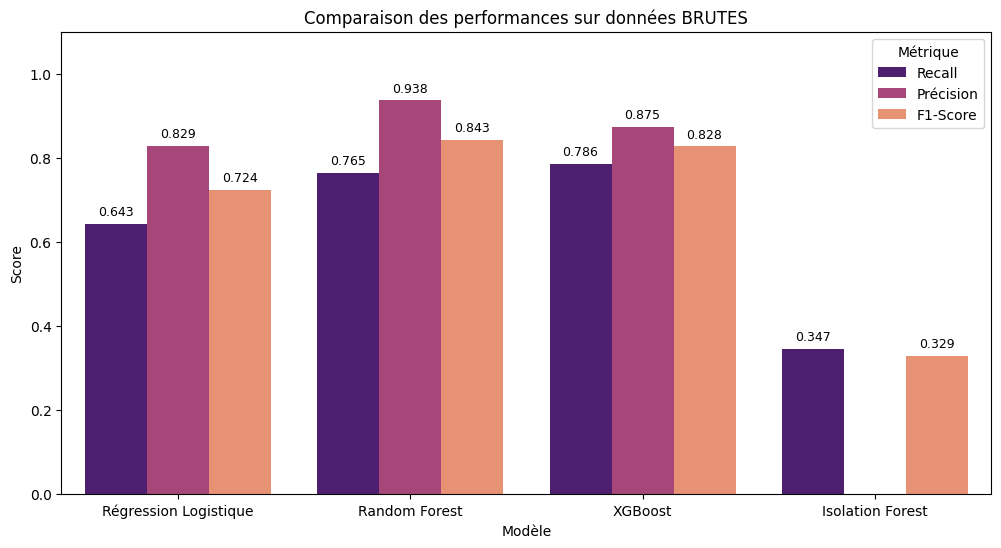

In [18]:
df_plot = df_compare.melt(id_vars=["Modèle", "Technique"], var_name="Métrique", value_name="Score")
df_plot["Score"] = pd.to_numeric(df_plot["Score"], errors='coerce')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x="Modèle", y="Score", hue="Métrique", palette="magma")
plt.title("Comparaison des performances sur données BRUTES")
plt.ylim(0, 1.1)

for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height():.3f}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', xytext=(0, 4),
                           textcoords='offset points', fontsize=9)
plt.show()

# Chapitre 4 — Résultats du Baseline

## 1. Analyse des Résultats

| Modèle | Recall (Détection) | F1-Score | Interprétation |
| :--- | :--- | :--- | :--- |
| **XGBoost** | **0.786** | 0.828 | Le plus performant, mais laisse passer 21% des fraudes. |
| **Random Forest** | 0.765 | **0.843** | Très précis, mais moins efficace sur la détection pure. |
| **Régression Logistique**| 0.643 | 0.724 | Trop simple pour capturer les schémas complexes. |
| **Isolation Forest** | 0.347 | 0.329 | Faible performance en détection non-supervisée ici. |

## 2. Le Problème du Déséquilibre (Class Imbalance)
Bien que l'**Accuracy** soit proche de 99.9%, le **Recall** plafonne à **78%** avec XGBoost. Cela signifie que dans un scénario réel :
* Près de **1 fraude sur 4** n'est pas détectée.
* Les modèles sont biaisés en faveur de la classe majoritaire car elle représente 99.8% des données.

## 3. Stratégie d'Amélioration
Trois techniques vont être testées pour corriger ce déséquilibre :
* **SMOTE** : Création de données synthétiques pour la classe minoritaire.
* **UnderSampling** : Réduction de la classe majoritaire.
* **Class Weights** : Pénalisation mathématique des erreurs sur les fraudes.

# Chapitre 5 : Techniques de Rééquilibrage

## 5.1 — SMOTE (Sur-échantillonnage Synthétique)

Le **SMOTE** génère de nouvelles transactions frauduleuses **synthétiques** en interpolant entre les exemples existants. L'objectif est d'atteindre un équilibre 50/50 dans le jeu d'entraînement.

> ✅ **Avantage** : On ne perd aucune donnée réelle.  
> ⚠️ **Risque** : On peut créer du "bruit" si les exemples minoritaires sont trop dispersés.

Avant SMOTE : {0: 227451, 1: 394}
Après SMOTE : {0: 227451, 1: 227451}


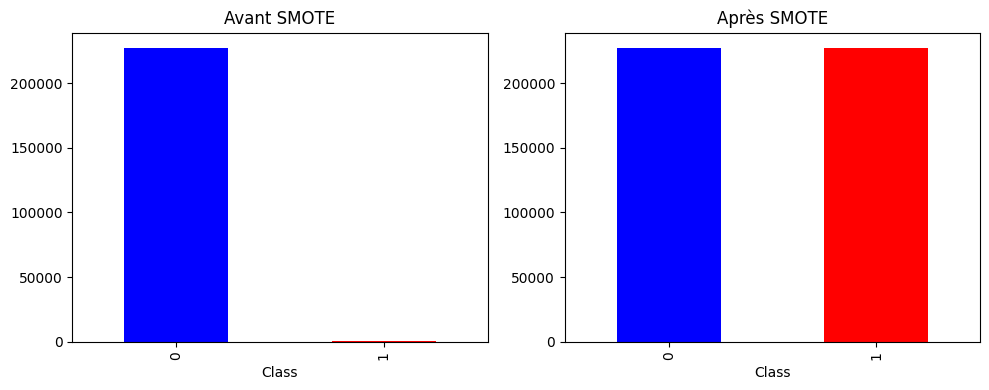

In [19]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts().to_dict())
print("Après SMOTE :", y_train_res.value_counts().to_dict())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
y_train.value_counts().plot(kind='bar', title='Avant SMOTE', color=['blue', 'red'], ax=ax1)
y_train_res.value_counts().plot(kind='bar', title='Après SMOTE', color=['blue', 'red'], ax=ax2)
plt.tight_layout()
plt.show()

In [20]:
models_smote = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42)
}

smote_results = []
for name, model in models_smote.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    smote_results.append({
        "Modèle": name, "Technique": "SMOTE",
        "Recall": recall_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

xgb_smote = models_smote["XGBoost"]
df_smote = pd.DataFrame(smote_results)
print("--- Résultats SMOTE ---")
print(df_smote.sort_values(by="Recall", ascending=False))

--- Résultats SMOTE ---
                  Modèle Technique    Recall  Précision  F1-Score
0  Régression Logistique     SMOTE  0.918367   0.055624  0.104895
1          Random Forest     SMOTE  0.877551   0.240896  0.378022
2                XGBoost     SMOTE  0.867347   0.745614  0.801887


C:\Users\aaron\AppData\Local\Temp\ipykernel_13064\1379597926.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modèle', y='F1-Score', data=df_smote, palette='rocket', ax=ax2)


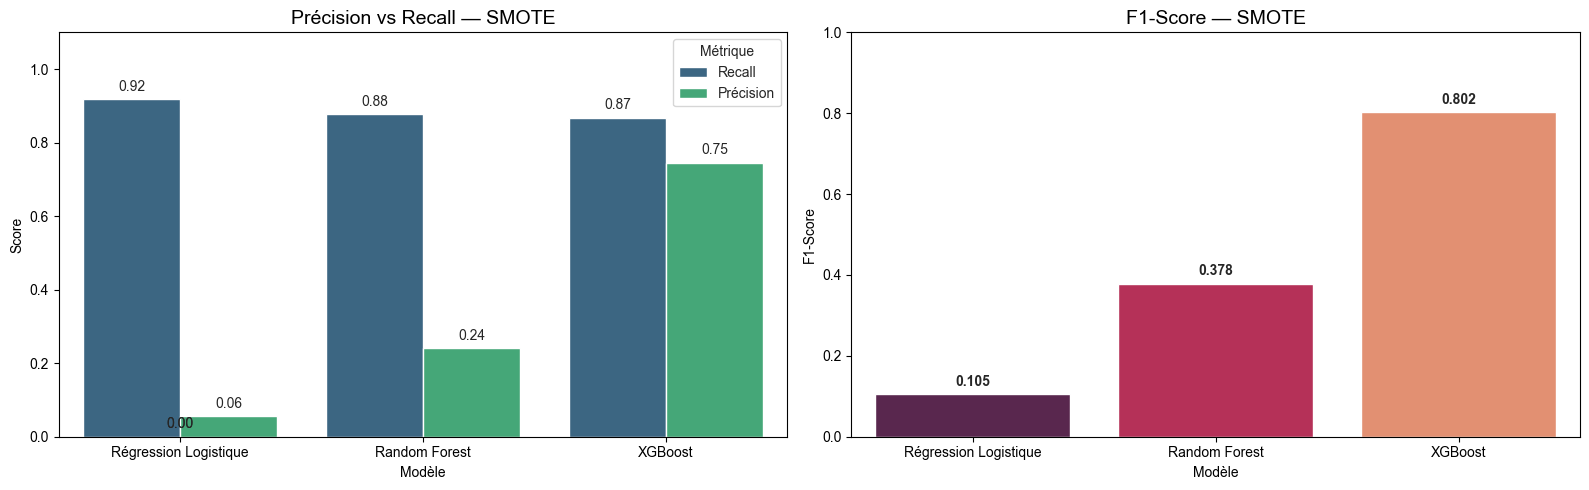

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

df_plot_smote = df_smote.melt(id_vars="Modèle", value_vars=["Recall", "Précision"],
                              var_name="Métrique", value_name="Score")
sns.barplot(data=df_plot_smote, x="Modèle", y="Score", hue="Métrique", palette="viridis", ax=ax1)
ax1.set_title("Précision vs Recall — SMOTE", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')

sns.barplot(x='Modèle', y='F1-Score', data=df_smote, palette='rocket', ax=ax2)
ax2.set_title("F1-Score — SMOTE", fontsize=14)
ax2.set_ylim(0, 1.0)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Chapitre 5.1 — Analyse de la technique SMOTE

### Synthèse des Performances
| Modèle | Recall | Précision | F1-Score | Statut |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost** | 0.867 | **0.745** | **0.801** | **Excellent équilibre** |
| **Random Forest** | 0.877 | 0.240 | 0.378 | Trop de Faux Positifs |
| **Régression Logistique** | **0.918** | 0.055 | 0.104 | Inexploitable (Trop bruyant) |

### Observations Clés
1. **XGBoost** est le seul à maintenir une précision élevée (74.5%) tout en capturant près de 87% des fraudes.
2. **La Régression Logistique** génère 19 fausses alertes pour chaque vraie fraude — coût opérationnel inacceptable.
3. **Le Random Forest** peine à distinguer les fraudes synthétiques des transactions normales.

**Conclusion** : Le SMOTE profite massivement aux algorithmes de Boosting, mais désoriente les modèles plus simples.

## 5.2 — UnderSampling (Sous-échantillonnage)

L'**UnderSampling** rééquilibre les classes en **supprimant aléatoirement** des transactions normales jusqu'à atteindre le même nombre que les fraudes.

> ✅ **Avantage** : Simple et rapide.  
> ⚠️ **Risque** : On perd ~280 000 exemples réels, ce qui peut appauvrir l'apprentissage.

In [22]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print(f"Taille du dataset après UnderSampling : {len(X_train_under)} lignes")

models_under = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, random_state=42)
}

under_results = []
for name, model in models_under.items():
    model.fit(X_train_under, y_train_under)
    y_pred_under = model.predict(X_test)
    under_results.append({
        "Modèle": name, "Technique": "UnderSampling",
        "Recall": recall_score(y_test, y_pred_under),
        "Précision": precision_score(y_test, y_pred_under),
        "F1-Score": f1_score(y_test, y_pred_under)
    })

df_under = pd.DataFrame(under_results)
print("--- Résultats UnderSampling ---")
print(df_under.sort_values(by="Recall", ascending=False))

Taille du dataset après UnderSampling : 788 lignes
--- Résultats UnderSampling ---
                  Modèle      Technique    Recall  Précision  F1-Score
0  Régression Logistique  UnderSampling  0.918367   0.037144  0.071400
2                XGBoost  UnderSampling  0.918367   0.032883  0.063492
1          Random Forest  UnderSampling  0.897959   0.059259  0.111181


C:\Users\aaron\AppData\Local\Temp\ipykernel_13064\3019788550.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modèle', y='F1-Score', data=df_under, palette='magma', ax=ax2)


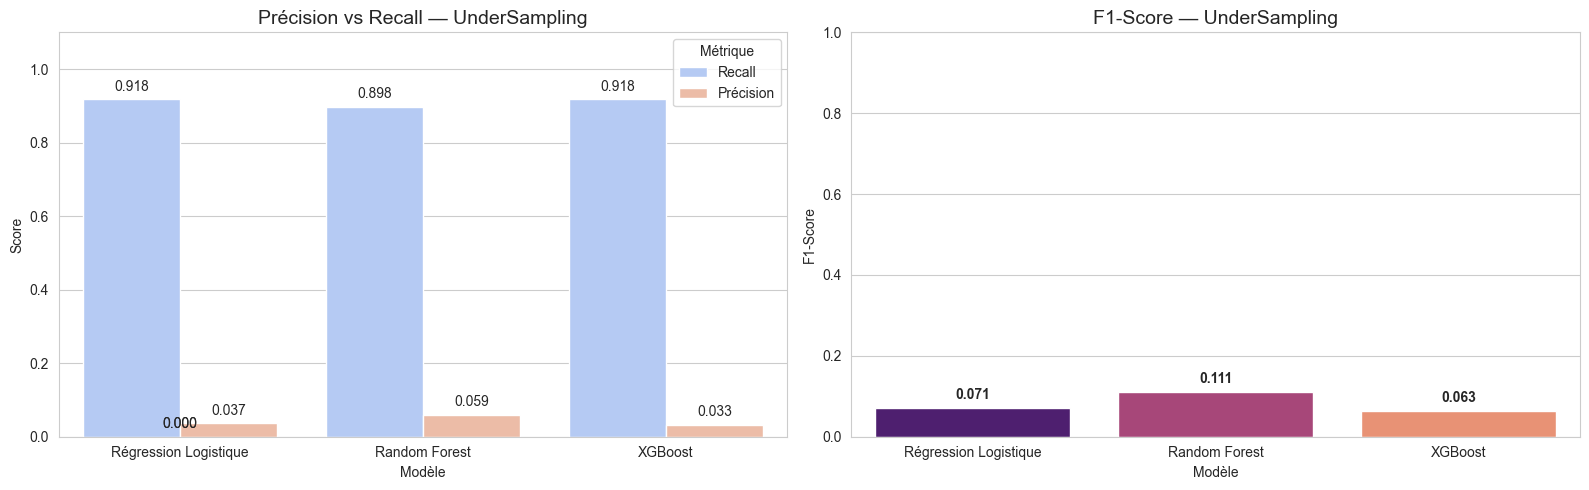

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

df_plot_under = df_under.melt(id_vars="Modèle", value_vars=["Recall", "Précision"],
                              var_name="Métrique", value_name="Score")
sns.barplot(data=df_plot_under, x="Modèle", y="Score", hue="Métrique", palette="coolwarm", ax=ax1)
ax1.set_title("Précision vs Recall — UnderSampling", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10)

sns.barplot(x='Modèle', y='F1-Score', data=df_under, palette='magma', ax=ax2)
ax2.set_title("F1-Score — UnderSampling", fontsize=14)
ax2.set_ylim(0, 1.0)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Chapitre 5.2 — Analyse de la technique UnderSampling

L'UnderSampling a réduit le dataset à ~788 lignes (50/50).

### Bilan des scores
* **Recall élevé mais artificiel** : Les modèles détectent bien les fraudes sur un jeu d'entraînement équilibré, mais la précision s'effondre sur les données réelles.
* **Précision < 6%** : Pour chaque vraie fraude détectée, le modèle génère ~17 fausses alertes — inacceptable en production.

### Conclusion
La technique est rejetée : supprimer 280 000 transactions normales prive les modèles d'informations essentielles sur ce qu'est un comportement normal.

## 5.3 — Class Weight (Pondération des Classes)

La technique du **Class Weight** ne modifie pas le dataset. Elle informe mathématiquement le modèle que **rater une fraude coûte beaucoup plus cher** que mal classifier une transaction normale.

- Pour `sklearn` : paramètre `class_weight='balanced'`
- Pour `XGBoost` : paramètre `scale_pos_weight = nb_normales / nb_fraudes`

> ✅ **Avantage** : On conserve toutes les données réelles, sans bruit synthétique.

In [24]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio utilisé pour XGBoost (scale_pos_weight) : {ratio:.1f}")

models_weight = {
    "Régression Logistique": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=ratio, random_state=42)
}

weight_results = []
for name, model in models_weight.items():
    model.fit(X_train, y_train)
    y_pred_weight = model.predict(X_test)
    weight_results.append({
        "Modèle": name, "Technique": "Class Weight",
        "Recall": recall_score(y_test, y_pred_weight),
        "Précision": precision_score(y_test, y_pred_weight),
        "F1-Score": f1_score(y_test, y_pred_weight)
    })

xgb_weight = models_weight["XGBoost"]
df_weight = pd.DataFrame(weight_results)
print("--- Résultats Class Weight ---")
print(df_weight.sort_values(by="Recall", ascending=False))

Ratio utilisé pour XGBoost (scale_pos_weight) : 577.3
--- Résultats Class Weight ---
                  Modèle     Technique    Recall  Précision  F1-Score
0  Régression Logistique  Class Weight  0.908163   0.056151  0.105764
1          Random Forest  Class Weight  0.867347   0.461957  0.602837
2                XGBoost  Class Weight  0.836735   0.891304  0.863158


C:\Users\aaron\AppData\Local\Temp\ipykernel_13064\75489371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modèle', y='F1-Score', data=df_weight, palette='magma', ax=ax2)


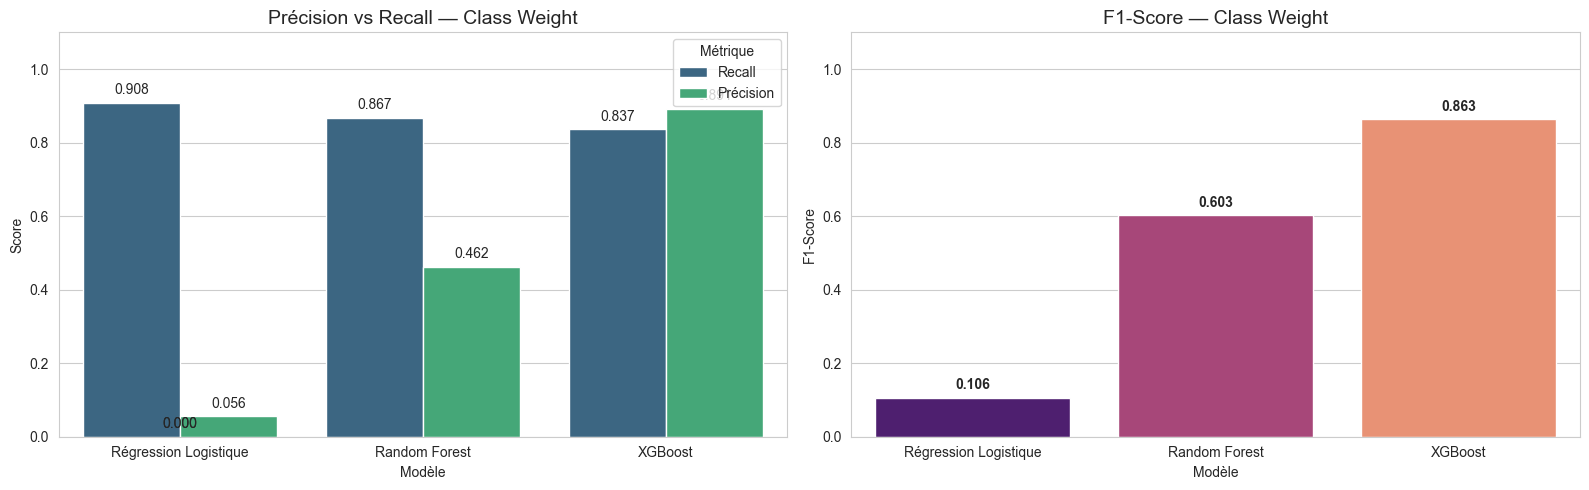

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

df_plot_weight = df_weight.melt(id_vars="Modèle", value_vars=["Recall", "Précision"],
                                var_name="Métrique", value_name="Score")
sns.barplot(data=df_plot_weight, x="Modèle", y="Score", hue="Métrique", palette="viridis", ax=ax1)
ax1.set_title("Précision vs Recall — Class Weight", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=10)

sns.barplot(x='Modèle', y='F1-Score', data=df_weight, palette='magma', ax=ax2)
ax2.set_title("F1-Score — Class Weight", fontsize=14)
ax2.set_ylim(0, 1.1)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

# Chapitre 5.3 — Analyse de la technique Class Weight

### Synthèse des Performances
| Modèle | Recall | Précision | F1-Score | Statut |
| :--- | :--- | :--- | :--- | :--- |
| **XGBoost** | 0.837 | **0.891** | **0.863** | **Vainqueur Indiscutable** |
| **Random Forest** | 0.867 | 0.462 | 0.603 | Performance Équilibrée |
| **Régression Logistique** | **0.908** | 0.056 | 0.106 | Trop de fausses alertes |

### Observations Clés
1. **XGBoost atteint 89.1% de précision** : sur 10 alertes levées, 9 sont de vraies fraudes — un résultat exceptionnel pour la production.
2. **Le Random Forest progresse** : contrairement au SMOTE ou à l'UnderSampling, il bénéficie ici de la conservation des données réelles (F1 = 0.60).
3. **La Régression Logistique reste limitée** : la pondération ne suffit pas à compenser sa linéarité face à des patterns complexes.

## Chapitre 6 : Comparaison Globale & Courbe Precision-Recall

Nous consolidons d'abord tous les résultats, puis nous évaluons les deux meilleurs modèles sur **tous les seuils possibles** via la courbe Precision-Recall.

> Comparer sur un seuil fixe de 0.50 peut être trompeur : la courbe **AP (Average Precision)** donne une vision plus complète de la robustesse d'un modèle.

In [26]:
df_final_comparison = pd.concat([df_compare, df_smote, df_under, df_weight], axis=0).reset_index(drop=True)
df_final_comparison = df_final_comparison.sort_values(by="F1-Score", ascending=False)

print("--- Top 5 des meilleures combinaisons Modèle / Technique ---")
print(df_final_comparison.head(5).to_string(index=False))

--- Top 5 des meilleures combinaisons Modèle / Technique ---
               Modèle   Recall  Précision  F1-Score    Technique
              XGBoost 0.836735   0.891304  0.863158 Class Weight
        Random Forest 0.765306   0.937500  0.842697 Donnée Brute
              XGBoost 0.785714   0.875000  0.827957 Donnée Brute
              XGBoost 0.867347   0.745614  0.801887        SMOTE
Régression Logistique 0.642857   0.828947  0.724138 Donnée Brute


In [27]:
# Calcul des courbes Precision-Recall pour les deux champions
y_scores_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_scores_weight = xgb_weight.predict_proba(X_test)[:, 1]

p_smote, r_smote, _ = precision_recall_curve(y_test, y_scores_smote)
p_weight, r_weight, _ = precision_recall_curve(y_test, y_scores_weight)
ap_smote = average_precision_score(y_test, y_scores_smote)
ap_weight = average_precision_score(y_test, y_scores_weight)

print(f"AP XGBoost + SMOTE        : {ap_smote:.3f}")
print(f"AP XGBoost + Class Weight : {ap_weight:.3f}")

AP XGBoost + SMOTE        : 0.872
AP XGBoost + Class Weight : 0.879


# Chapitre 7 : Duel Final — SMOTE vs Class Weight

Deux stratégies se distinguent nettement sur le modèle **XGBoost** :
1. **SMOTE** (sur-échantillonnage synthétique)
2. **Class Weight** (pondération par `scale_pos_weight`)

La courbe **Precision-Recall** et l'**AP** permettent de les comparer sur l'ensemble des seuils de décision, pas seulement à 0.50.

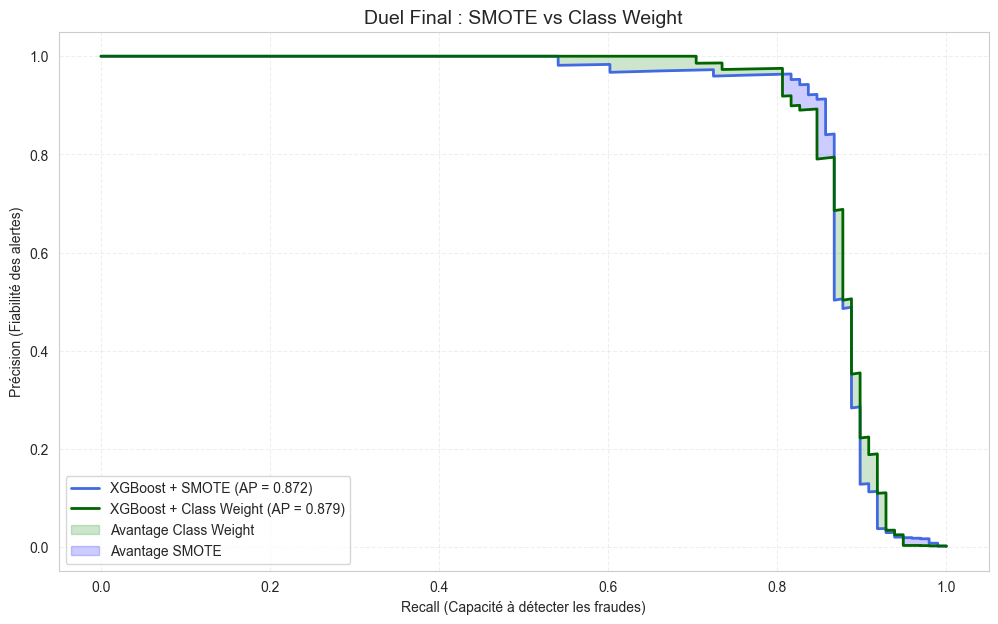

In [28]:
common_recall = np.linspace(0, 1, 1000)
interp_p_smote = np.interp(common_recall, r_smote[::-1], p_smote[::-1])
interp_p_weight = np.interp(common_recall, r_weight[::-1], p_weight[::-1])

plt.figure(figsize=(12, 7))
plt.plot(r_smote, p_smote, label=f'XGBoost + SMOTE (AP = {ap_smote:.3f})', color='royalblue', lw=2)
plt.plot(r_weight, p_weight, label=f'XGBoost + Class Weight (AP = {ap_weight:.3f})', color='darkgreen', lw=2)

plt.fill_between(common_recall, interp_p_weight, interp_p_smote,
                 where=(interp_p_weight >= interp_p_smote),
                 color='green', alpha=0.2, label='Avantage Class Weight')
plt.fill_between(common_recall, interp_p_weight, interp_p_smote,
                 where=(interp_p_weight < interp_p_smote),
                 color='blue', alpha=0.2, label='Avantage SMOTE')

plt.xlabel('Recall (Capacité à détecter les fraudes)')
plt.ylabel('Précision (Fiabilité des alertes)')
plt.title('Duel Final : SMOTE vs Class Weight', fontsize=14)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Interprétation du Duel Final

Le graphique confirme la supériorité de l'approche **Class Weight** :

1. **Performance Globale** : L'AP du Class Weight est supérieur, indiquant de meilleures performances sur l'ensemble des seuils.
2. **Stabilité Opérationnelle** : La zone verte couvre la plage de Recall la plus critique (0.55–0.80), où le modèle maintient une précision quasi parfaite — limitant les faux positifs coûteux.
3. **Avantage SMOTE marginal** : La zone bleue n'apparaît que pour des Recall très élevés (> 82%), là où la précision s'effondre de toute façon pour les deux modèles.

---
**✅ Conclusion finale** : Le modèle **XGBoost + Class Weight** est retenu comme modèle de production. Il offre la meilleure fiabilité sur la plage d'utilisation réelle du système de détection de fraude.